In [1]:
!python --version

!pip install evaluate
!pip install rouge_score
!pip install bert_score
!pip install -U bitsandbytes

Python 3.12.12


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments, GenerationConfig, GenerationConfig, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType, prepare_model_for_kbit_training
from datasets import load_dataset
from copy import deepcopy
from math import floor
import numpy as np
import evaluate
import random
import torch
import time

In [3]:
import torch
torch.cuda.is_available()

True

In [4]:
# ===== seed =====
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# -------- data config --------
DATASET_NAME = "databricks/databricks-dolly-15k"
PERCENT = 0.15  # 5% percentage of dataset taken.
TRAIN_FRAC = 0.8
DEV_FRAC   = 0.133

# -------- model config --------
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
LEARNING_RATE = 2e-4
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# -------- train config --------
EPOCHS = 1
BATCH_SIZE = 32
MAX_LENGTH = 128
WEIGHT_DECAY = 0.0
LOGGING_STEPS = 50

In [5]:
# 1. Cargar el dataset
dataset = load_dataset("databricks/databricks-dolly-15k", split="train")
dataset = dataset.class_encode_column("category")

# 2. Downsample equilibrado: Dolly tiene varias categorías (closed_qa, summarization, etc.)
# Seleccionamos una fracción manteniendo la diversidad de tareas
ds_dict = dataset.train_test_split(train_size=PERCENT, seed=SEED, stratify_by_column="category")
subset_10 = ds_dict["train"]

# 1. Separar el Test Set (siguiendo el requisito de ~1k, pero ajustado al 10% total sería menos)
# Si quieres mantener el ratio 12/2/1 sobre las 1,500 muestras:
temp_split = subset_10.train_test_split(test_size=(1-TRAIN_FRAC-DEV_FRAC), seed=SEED)
test_ds = temp_split["test"] # ~100 muestras

# 2. Separar Train y Dev del resto
train_dev_split = temp_split["train"].train_test_split(test_size=DEV_FRAC, seed=SEED)
train_ds = train_dev_split["train"]
dev_ds = train_dev_split["test"]

print(f"Subsets finales: Train: {len(train_ds)} | Dev: {len(dev_ds)} | Test: {len(test_ds)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token_id = tokenizer.eos_token_id


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Subsets finales: Train: 1820 | Dev: 280 | Test: 151


In [6]:
def tokenize_function(example):
    # Formateamos el texto
    text = f"Instruction:\n{example['instruction']}\n\nResponse:\n{example['response']}"

    # Tokenizamos
    tokenized = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length"
    )

    # Para CausalLM, las etiquetas suelen ser una copia de los input_ids
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

# Aplicar tokenización eliminando TODAS las columnas originales
column_names = dataset.column_names # ["instruction", "context", "response", "category"]

train_ds_tokenized = train_ds.map(
    tokenize_function,
    remove_columns=column_names,
    batched=False
)

dev_ds_tokenized = dev_ds.map(
    tokenize_function,
    remove_columns=column_names,
    batched=False
)

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

In [7]:
output_dir = f'./huggingface-finetuning-training-{str(int(time.time()))}'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, quantization_config=bnb_config, device_map="auto")

lora_config = LoraConfig(
    r = LORA_R,
    lora_alpha = LORA_ALPHA,
    target_modules=["q_proj", "v_proj"],
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    task_type=TaskType.CAUSAL_LM
)

base_model = prepare_model_for_kbit_training(base_model)
lora_model = get_peft_model(deepcopy(base_model), lora_config)

training_args = TrainingArguments(
    output_dir=output_dir,
    auto_find_batch_size=True,
    learning_rate=LEARNING_RATE,
    num_train_epochs=EPOCHS,
    logging_steps=LOGGING_STEPS,
    remove_unused_columns=False,
    save_strategy="no",
    report_to="none",
)

lora_trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=dev_ds_tokenized,
)

In [8]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats() # Reinicia el contador de memoria pico

train_result = lora_trainer.train()

# Memoria
allocated_memory = torch.cuda.memory_allocated() / (1024 ** 3) # Memoria que realmente contienen pesos, gradientes y activaciones
peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3) # Convertir bytes a GB
print(f"\nMemoria Activa: {allocated_memory:.2f} GB")
print(f"Consumo máximo de VRAM: {peak_memory:.2f} GB")

# Tiempo
training_time = train_result.metrics['train_runtime']
print(f"\nTiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Muestras por segundo: {train_result.metrics['train_samples_per_second']:.2f}")

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
50,2.133300
100,1.175100
150,1.208300
200,1.230000



Memoria Activa: 2.10 GB
Consumo máximo de VRAM: 2.65 GB

Tiempo total de entrenamiento: 699.39 segundos
Muestras por segundo: 2.60


## Evaluation

### Métricas

In [9]:
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")

tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token

gen_cfg = GenerationConfig(
    max_new_tokens=128,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)

def generate(model, ds, batch_size=8):
    model.eval()
    preds = []
    start = time.time()
    total_tokens = 0

    # Usamos un DataLoader o un loop simple sobre el dataset
    for i in range(0, len(ds), batch_size):
        batch = ds[i:i+batch_size]
        # Aseguramos el mismo formato que usamos en el entrenamiento
        prompts = [f"Instruction:\n{x}\n\nResponse:\n" for x in batch["instruction"]]

        inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            # Generación con el config definido
            out = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                generation_config=gen_cfg
            )

        # Extraemos solo los tokens nuevos (la respuesta)
        gen_tokens = out[:, input_len:]
        total_tokens += gen_tokens.numel()

        # Decodificamos
        decoded_preds = tokenizer.batch_decode(gen_tokens, skip_special_tokens=True)
        # Limpieza básica de strings
        preds += [p.strip() for p in decoded_preds]

    # Sincronización para medición de tiempo real en GPU
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    duration = time.time() - start
    throughput = total_tokens / duration
    return preds, throughput

# Referencias reales
refs = test_ds["response"]

# 1. Evaluación del modelo con LoRA activado
print("Evaluando modelo con LoRA...")
lora_preds, lora_tp = generate(lora_model, test_ds)

# 2. Desactivar LoRA para evaluar el modelo base "puro"
with lora_model.disable_adapter():
    print("Evaluando modelo base (LoRA desactivado)...")
    orig_preds, orig_tp = generate(lora_model, test_ds)

### 3. Cálculo de Métricas
def compute_metrics(predictions, references, name="Modelo"):
    print(f"\n--- Resultados: {name} ---")

    # ROUGE
    results_rouge = rouge.compute(predictions=predictions, references=references)
    print(f"ROUGE: {results_rouge}")

    # BLEU (requiere referencias como lista de listas)
    results_bleu = bleu.compute(predictions=predictions, references=[[r] for r in references])
    print(f"BLEU: {results_bleu['bleu']:.4f}")

    # BERTScore
    results_bert = bertscore.compute(
        predictions=predictions,
        references=references,
        lang="en",
        model_type="bert-base-uncased",
        device="cuda" if torch.cuda.is_available() else "cpu"
    )
    mean_f1 = np.mean(results_bert["f1"])
    print(f"BERTScore F1 (Mean): {mean_f1:.4f}")

    return {"rouge": results_rouge, "bleu": results_bleu, "bert": mean_f1}

# Ejecutar comparativa
metrics_orig = compute_metrics(orig_preds, refs, "Base Model")
metrics_lora = compute_metrics(lora_preds, refs, "LoRA Model")

print(f"\nThroughput Base: {orig_tp:.2f} tokens/s")
print(f"Throughput LoRA: {lora_tp:.2f} tokens/s")

Evaluando modelo con LoRA...
Evaluando modelo base (LoRA desactivado)...

--- Resultados: Base Model ---
ROUGE: {'rouge1': np.float64(0.28788268040986126), 'rouge2': np.float64(0.10285264684016926), 'rougeL': np.float64(0.2186034679325854), 'rougeLsum': np.float64(0.23248383825186736)}
BLEU: 0.0617


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERTScore F1 (Mean): 0.5592

--- Resultados: LoRA Model ---
ROUGE: {'rouge1': np.float64(0.3150165698473364), 'rouge2': np.float64(0.13910916198745477), 'rougeL': np.float64(0.24682624924106794), 'rougeLsum': np.float64(0.25666608724846773)}
BLEU: 0.0633
BERTScore F1 (Mean): 0.5853

Throughput Base: 61.58 tokens/s
Throughput LoRA: 60.84 tokens/s


### Evaluación humana

In [10]:
gen_cfg = GenerationConfig(
    max_new_tokens=100,
    do_sample=False,
    num_beams=1,
    pad_token_id=tokenizer.eos_token_id,
)

nums = random.sample(range(len(test_ds)), k=5)
dash_line = "-" * 100

base_model.eval()
lora_model.eval()

for idx, i in enumerate(nums):
    instruction = test_ds[i]["instruction"]
    reference = test_ds[i]["response"]

    prompt = f"Instruction: {instruction}\nReponse:"
    inputs = tokenizer(prompt, return_tensors="pt").to(base_model.device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        # Original
        out_orig = base_model.generate(**inputs, generation_config=gen_cfg)
        text_orig = tokenizer.decode(out_orig[0], skip_special_tokens=True)

        # LoRA
        out_lora = lora_model.generate(**inputs, generation_config=gen_cfg)
        text_lora = tokenizer.decode(out_lora[0], skip_special_tokens=True)

    print(dash_line)
    print(f"MUESTRA {idx}:")
    print(f'\nPROMPT:\n{prompt}')
    print(f'\nBASELINE HUMAN SUMMARY:\n{reference}')
    print(f'\nORIGINAL MODEL:\n{text_orig}')
    print(f'\nINSTRUCT MODEL:\n{text_lora}')

----------------------------------------------------------------------------------------------------
MUESTRA 0:

PROMPT:
Instruction: What can be done to resolve issues with climate change
Reponse:

BASELINE HUMAN SUMMARY:
Climate change is dangerous as it alters the climate very rapidly leading to shift in seasons and damaging the habitats of wild life for example. Some ways to control it could be: 
1. Reduce air pollution - move towards electric vehicles. Also move towards renewable source of energy so that increased demand can be met.
2. Control ozone depletion - Ban use of chemicals that encourage ozone hole depletion as this leads to melting of polar ice caps.
3. Plant more trees - They help in regulating the environment.

ORIGINAL MODEL:
Instruction: What can be done to resolve issues with climate change
Reponse: The United Nations Framework Convention on Climate Change (UNFCCC) is a global treaty that aims to limit global warming to well below 2 degrees Celsius above pre-industr

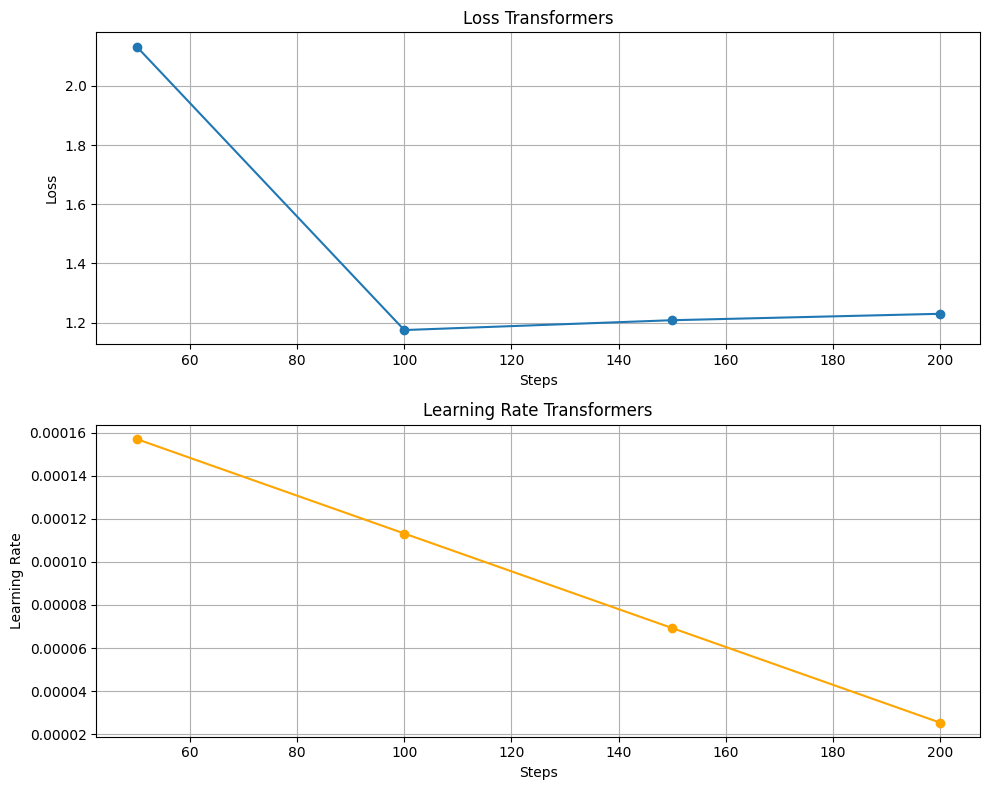

In [12]:
import matplotlib.pyplot as plt

# Extraer datos
losses = [x["loss"] for x in lora_trainer.state.log_history if "loss" in x]
lrs = [x["learning_rate"] for x in lora_trainer.state.log_history if "learning_rate" in x]
steps_loss = [x["step"] for x in lora_trainer.state.log_history if "loss" in x]
steps_lr = [x["step"] for x in lora_trainer.state.log_history if "learning_rate" in x]

# Crear figura con 2 subplots
fig, axs = plt.subplots(2, 1, figsize=(10,8))

# Loss
axs[0].plot(steps_loss, losses, marker='o', linestyle='-')
axs[0].set_xlabel("Steps")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss Transformers")
axs[0].grid(True)

# Learning Rate
axs[1].plot(steps_lr, lrs, marker='o', linestyle='-', color='orange')
axs[1].set_xlabel("Steps")
axs[1].set_ylabel("Learning Rate")
axs[1].set_title("Learning Rate Transformers")
axs[1].grid(True)

plt.tight_layout()
plt.show()